# 查看Pipeline支持的任务类型

In [2]:
from transformers.pipelines import SUPPORTED_TASKS

In [3]:
from pprint import pprint
pprint(SUPPORTED_TASKS.keys())

dict_keys(['audio-classification', 'automatic-speech-recognition', 'text-to-audio', 'feature-extraction', 'text-classification', 'token-classification', 'table-question-answering', 'document-question-answering', 'fill-mask', 'text-generation', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-audio-classification', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'object-detection', 'zero-shot-object-detection', 'depth-estimation', 'video-classification', 'mask-generation', 'keypoint-matching', 'any-to-any'])


In [4]:
for k, v in SUPPORTED_TASKS.items():
    print(k, v)

audio-classification {'impl': <class 'transformers.pipelines.audio_classification.AudioClassificationPipeline'>, 'pt': (<class 'transformers.models.auto.modeling_auto.AutoModelForAudioClassification'>,), 'default': {'model': ('superb/wav2vec2-base-superb-ks', '372e048')}, 'type': 'audio'}
automatic-speech-recognition {'impl': <class 'transformers.pipelines.automatic_speech_recognition.AutomaticSpeechRecognitionPipeline'>, 'pt': (<class 'transformers.models.auto.modeling_auto.AutoModelForCTC'>, <class 'transformers.models.auto.modeling_auto.AutoModelForTDT'>, <class 'transformers.models.auto.modeling_auto.AutoModelForSpeechSeq2Seq'>), 'default': {'model': ('facebook/wav2vec2-base-960h', '22aad52')}, 'type': 'multimodal'}
text-to-audio {'impl': <class 'transformers.pipelines.text_to_audio.TextToAudioPipeline'>, 'pt': (<class 'transformers.models.auto.modeling_auto.AutoModelForTextToWaveform'>, <class 'transformers.models.auto.modeling_auto.AutoModelForTextToSpectrogram'>), 'default': {'m

# Pipeline的创建与使用方式

In [1]:
from transformers import pipeline, TextClassificationPipeline

## 根据任务类型直接创建Pipeline, 默认都是英文的模型

In [8]:
pipe = pipeline("text-classification")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 5110.99it/s]


In [10]:
pipe

TextClassificationPipeline: {'model': 'DistilBertForSequenceClassification', 'dtype': 'float32', 'device': 'cuda', 'input_modalities': 'text'}

In [11]:
pipe(["very good!", "vary bad!"])

[{'label': 'POSITIVE', 'score': 0.9998525381088257},
 {'label': 'NEGATIVE', 'score': 0.9991207718849182}]

## 指定任务类型，再指定模型，创建基于指定模型的Pipeline

In [14]:
# https://huggingface.co/models
pipe = pipeline("text-classification", model="uer/roberta-base-finetuned-dianping-chinese")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 20621.67it/s]


In [13]:
pipe("我觉得不太行！")

[{'label': 'negative (stars 1, 2 and 3)', 'score': 0.9735506772994995}]

## 预先加载模型，再创建Pipeline

In [15]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# 这种方式，必须同时指定model和tokenizer
model = AutoModelForSequenceClassification.from_pretrained("uer/roberta-base-finetuned-dianping-chinese")
tokenizer = AutoTokenizer.from_pretrained("uer/roberta-base-finetuned-dianping-chinese")
pipe = pipeline("text-classification", model=model, tokenizer=tokenizer)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 17566.58it/s]


In [16]:
pipe("我觉得不太行！")

[{'label': 'negative (stars 1, 2 and 3)', 'score': 0.9735506772994995}]

In [17]:
pipe.model.device

device(type='cuda', index=0)

In [18]:
import torch
import time
times = []
for i in range(100):
    torch.cuda.synchronize()
    start = time.time()
    pipe("我觉得不太行！")
    torch.cuda.synchronize()
    end = time.time()
    times.append(end - start)
print(sum(times) / 100)

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


0.01398378849029541


## 使用GPU进行推理

In [19]:
pipe = pipeline("text-classification", model="uer/roberta-base-finetuned-dianping-chinese", device=0)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 29271.73it/s]


In [20]:
pipe.model.device

device(type='cuda', index=0)

In [21]:
import torch
import time
times = []
for i in range(100):
    torch.cuda.synchronize()
    start = time.time()
    pipe("我觉得不太行！")
    torch.cuda.synchronize()
    end = time.time()
    times.append(end - start)
print(sum(times) / 100)

0.014909789562225342


## 确定Pipeline参数

In [22]:
qa_pipe = pipeline("question-answering", model="uer/roberta-base-chinese-extractive-qa")

KeyError: "Unknown task question-answering, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"

In [ ]:
qa_pipe

In [ ]:
QuestionAnsweringPipeline

In [ ]:
qa_pipe(question="中国的首都是哪里？", context="中国的首都是北京", max_answer_len=1)

# 其他Pipeline示例

In [3]:
checkpoint = "google/owlvit-base-patch32"
detector = pipeline(model=checkpoint, task="zero-shot-object-detection")

Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

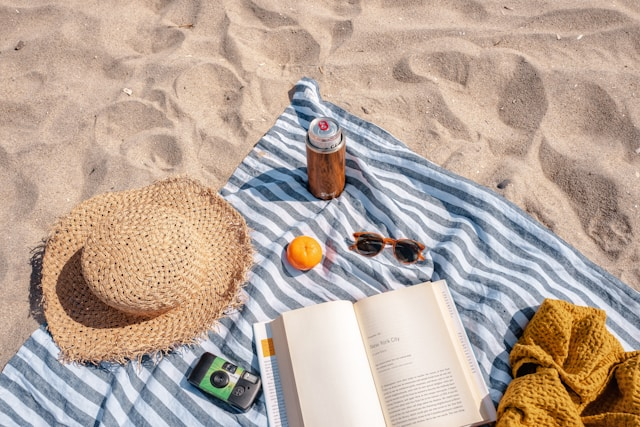

In [4]:
import requests
from PIL import Image

url = "https://unsplash.com/photos/oj0zeY2Ltk4/download?ixid=MnwxMjA3fDB8MXxzZWFyY2h8MTR8fHBpY25pY3xlbnwwfHx8fDE2Nzc0OTE1NDk&force=true&w=640"
im = Image.open(requests.get(url, stream=True).raw)
im

In [5]:
predictions = detector(
    im,
    candidate_labels=["hat", "sunglasses", "book"],
)
predictions

[{'score': 0.2592524588108063,
  'label': 'sunglasses',
  'box': {'xmin': 349, 'ymin': 228, 'xmax': 430, 'ymax': 265}},
 {'score': 0.18528592586517334,
  'label': 'book',
  'box': {'xmin': 270, 'ymin': 284, 'xmax': 502, 'ymax': 427}},
 {'score': 0.11255776882171631,
  'label': 'hat',
  'box': {'xmin': 39, 'ymin': 173, 'xmax': 260, 'ymax': 363}}]

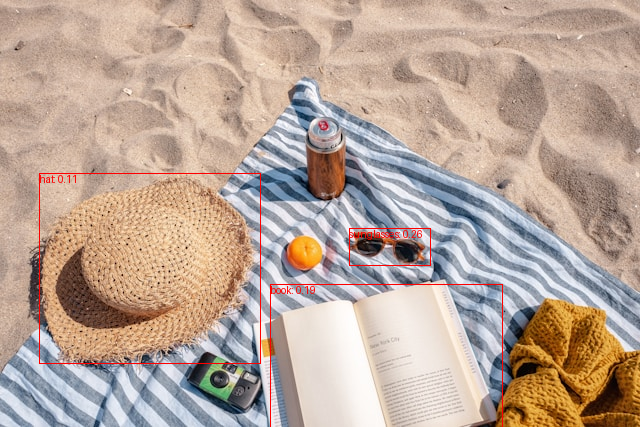

In [6]:
from PIL import ImageDraw

draw = ImageDraw.Draw(im)

for prediction in predictions:
    box = prediction["box"]
    label = prediction["label"]
    score = prediction["score"]
    xmin, ymin, xmax, ymax = box.values()
    draw.rectangle((xmin, ymin, xmax, ymax), outline="red", width=1)
    draw.text((xmin, ymin), f"{label}: {round(score,2)}", fill="red")

im

# Pipeline背后的实现

In [7]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

In [8]:
tokenizer = AutoTokenizer.from_pretrained("uer/roberta-base-finetuned-dianping-chinese")
model = AutoModelForSequenceClassification.from_pretrained("uer/roberta-base-finetuned-dianping-chinese")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [9]:
input_text = "我觉得不太行！"
inputs = tokenizer(input_text, return_tensors="pt")
inputs

{'input_ids': tensor([[ 101, 2769, 6230, 2533,  679, 1922, 6121, 8013,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [10]:
res = model(**inputs)
res

SequenceClassifierOutput(loss=None, logits=tensor([[ 1.7376, -1.8681]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

In [11]:
logits = res.logits
logits = torch.softmax(logits, dim=-1)
logits

tensor([[0.9736, 0.0264]], grad_fn=<SoftmaxBackward0>)

In [12]:
pred = torch.argmax(logits).item()
pred

0

In [13]:
model.config.id2label

{0: 'negative (stars 1, 2 and 3)', 1: 'positive (stars 4 and 5)'}

In [14]:
result = model.config.id2label.get(pred)
result

'negative (stars 1, 2 and 3)'